In [30]:
# ============================================================
# Multimodal Vasopressor Prediction with Monte Carlo Dropout
# MDS-ED tabular data
#
# Target:
#   deterioration_vasopressors
#
# Features:
#   demographics + biometrics + vitals + labvalues
#
# Uncertainty:
#   Monte Carlo Dropout
#
# Metrics:
#   AUROC
#   AUPRC
#   Brier Score
#   Predictive Uncertainty
#
# ============================================================

import pandas as pd
import numpy as np
import warnings

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")


In [3]:

# ============================================================
# 1. Load dataset
# ============================================================


print("Loading dataset...")

from pathlib import Path

csv_path = r"C:\Users\Taki Djebbar\Documents\Data Science S1\Medical Data Analysis with Deep Learning\mds_ed.csv"
df = pd.read_csv(csv_path, low_memory=False)

print("Dataset shape:", df.shape)


Loading dataset...
Dataset shape: (129057, 1936)


In [4]:

# ============================================================
# 2. Define features
# ============================================================

demographics_columns = [
    c for c in df.columns if "demographics_" in c
]

biometrics_columns = [
    c for c in df.columns if "biometrics_" in c
]

vitals_columns = [
    c for c in df.columns if "vitals_" in c
]

labvalues_columns = [
    c for c in df.columns if "labvalues_" in c
]

features = (
    demographics_columns +
    biometrics_columns +
    vitals_columns +
    labvalues_columns
)

target_col = "deterioration_vasopressors"

print("Number of features:", len(features))


Number of features: 470


In [5]:

# ============================================================
# 3. Remove invalid labels
# ============================================================

df = df[df[target_col] != -999]
df = df[df[target_col].notna()]

df[target_col] = df[target_col].astype(int)

print("Remaining rows:", len(df))


Remaining rows: 129057


In [6]:

# ============================================================
# 4. Train / Validation / Test split
# ============================================================

train_df = df[
    df["general_strat_fold"].isin(range(0, 18))
].reset_index(drop=True)

val_df = df[
    df["general_strat_fold"] == 18
].reset_index(drop=True)

test_df = df[
    df["general_strat_fold"] == 19
].reset_index(drop=True)


In [7]:

# ============================================================
# 5. Use first ECG only for val/test
# ============================================================

val_df = val_df[
    val_df["general_ecg_no_within_stay"] == 0
]

test_df = test_df[
    test_df["general_ecg_no_within_stay"] == 0
]


In [8]:

# ============================================================
# 6. Extract arrays
# ============================================================

x_train = train_df[features]
x_val = val_df[features]
x_test = test_df[features]

y_train = train_df[target_col].values
y_val = val_df[target_col].values
y_test = test_df[target_col].values

print("Train:", x_train.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)


Train: (116433, 470)
Validation: (5824, 470)
Test: (6080, 470)


In [9]:

# ============================================================
# 7. Median imputation
# ============================================================

imputer = SimpleImputer(strategy="median")

x_train = imputer.fit_transform(x_train)
x_val = imputer.transform(x_val)
x_test = imputer.transform(x_test)


In [10]:

# ============================================================
# 8. Standardization
# ============================================================

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)


In [11]:

# ============================================================
# 9. Convert to tensors
# ============================================================

x_train = torch.tensor(x_train, dtype=torch.float32)
x_val = torch.tensor(x_val, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)


In [12]:

# ============================================================
# 10. Data loaders
# ============================================================

batch_size = 256

train_loader = DataLoader(
    TensorDataset(x_train, y_train),
    batch_size=batch_size,
    shuffle=True
)


In [13]:

# ============================================================
# 11. RealMLP model with dropout
# ============================================================

class RealMLP(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.30),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.30),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.20),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.network(x)

model = RealMLP(input_dim=x_train.shape[1])


In [14]:

# ============================================================
# 12. Loss and optimizer
# ============================================================

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


In [15]:

# ============================================================
# 13. Training
# ============================================================

epochs = 20

print("\nTraining model...\n")

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for xb, yb in train_loader:

        optimizer.zero_grad()

        outputs = model(xb).squeeze()

        loss = criterion(outputs, yb)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {total_loss:.4f}"
    )



Training model...

Epoch 1/20 | Loss: 84.7073
Epoch 2/20 | Loss: 20.5707
Epoch 3/20 | Loss: 18.0673
Epoch 4/20 | Loss: 16.9744
Epoch 5/20 | Loss: 16.5912
Epoch 6/20 | Loss: 15.8740
Epoch 7/20 | Loss: 15.1331
Epoch 8/20 | Loss: 14.5693
Epoch 9/20 | Loss: 14.4029
Epoch 10/20 | Loss: 13.4907
Epoch 11/20 | Loss: 13.1609
Epoch 12/20 | Loss: 12.5980
Epoch 13/20 | Loss: 12.1115
Epoch 14/20 | Loss: 11.6656
Epoch 15/20 | Loss: 11.0240
Epoch 16/20 | Loss: 10.5344
Epoch 17/20 | Loss: 10.3913
Epoch 18/20 | Loss: 9.9359
Epoch 19/20 | Loss: 9.3745
Epoch 20/20 | Loss: 9.3381


In [35]:

# ============================================================
# 14. Monte Carlo Dropout Prediction
# ============================================================
#
# We keep dropout ACTIVE during inference
# and run multiple forward passes.
#
# Each pass gives slightly different predictions.
#
# Variability across predictions = uncertainty
#
# ============================================================

def mc_dropout_predict(model, x, n_samples=50):

    model.train()  # IMPORTANT: activates dropout

    predictions = []

    with torch.no_grad():

        for _ in range(n_samples):

            logits = model(x).squeeze()

            probs = torch.sigmoid(logits)

            predictions.append(probs.numpy())

    predictions = np.array(predictions)

    # Mean prediction
    mean_pred = predictions.mean(axis=0)

    # Variance = epistemic uncertainty
    # --------------------------------------------------------
    uncertainty = predictions.var(axis=0)

    return mean_pred, uncertainty

print("\nRunning Monte Carlo Dropout...")

y_pred_mean, y_uncertainty = mc_dropout_predict(
    model,
    x_test,
    n_samples=50
)



Running Monte Carlo Dropout...


In [36]:

# ============================================================
# 15. Metrics
# ============================================================

auroc = roc_auc_score(y_test, y_pred_mean)

auprc = average_precision_score(y_test, y_pred_mean)

brier = brier_score_loss(y_test, y_pred_mean)

mean_uncertainty = y_uncertainty.mean()


In [37]:

# ============================================================
# 16. Save prediction-level uncertainty
# ============================================================

predictions_df = pd.DataFrame({
    "y_true": y_test,
    "prediction": y_pred_mean,
    "uncertainty_std": y_uncertainty
})

predictions_df.to_csv(
    "vasopressor_mc_predictions_Monte_Carlo.csv",
    index=False
)


In [38]:

# ============================================================
# 17. Save summary results
# ============================================================

results = pd.DataFrame([{
    "target": target_col,
    "auroc": auroc,
    "auprc": auprc,
    "brier_score": brier,
    "mean_uncertainty": mean_uncertainty,
    "test_n": len(y_test),
    "positive_rate": y_test.mean()
}])

results.to_csv(
    "vasopressor_mc_results_Monte_Carlo.csv",
    index=False
)


In [39]:

# ============================================================
# 18. Print results
# ============================================================

print("\n===== FINAL RESULTS =====")

print(results.to_string(index=False))

print("\nPrediction-level uncertainty saved to:")
print("vasopressor_mc_predictions_Monte_Carlo.csv")

print("\nSummary results saved to:")
print("vasopressor_mc_results_Monte_Carlo.csv")


===== FINAL RESULTS =====
                    target    auroc   auprc  brier_score  mean_uncertainty  test_n  positive_rate
deterioration_vasopressors 0.853222 0.10115     0.008937          0.000773    6080       0.008882

Prediction-level uncertainty saved to:
vasopressor_mc_predictions_Monte_Carlo.csv

Summary results saved to:
vasopressor_mc_results_Monte_Carlo.csv


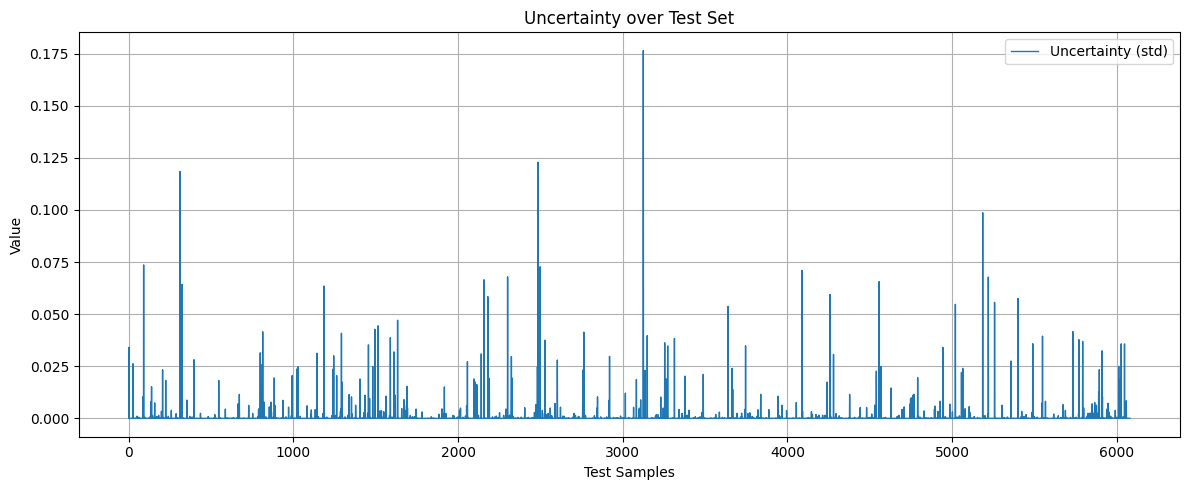

In [40]:
x = np.arange(1, 6081)
plt.figure(figsize=(12, 5))

# Plot prediction
#plt.plot(x, y_pred_mean, label="Prediction (mean)", linewidth=1)

# Plot uncertainty
plt.plot(x, y_uncertainty, label="Uncertainty (std)", linewidth=1)

plt.xlabel("Test Samples")
plt.ylabel("Value")
plt.title("Uncertainty over Test Set")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

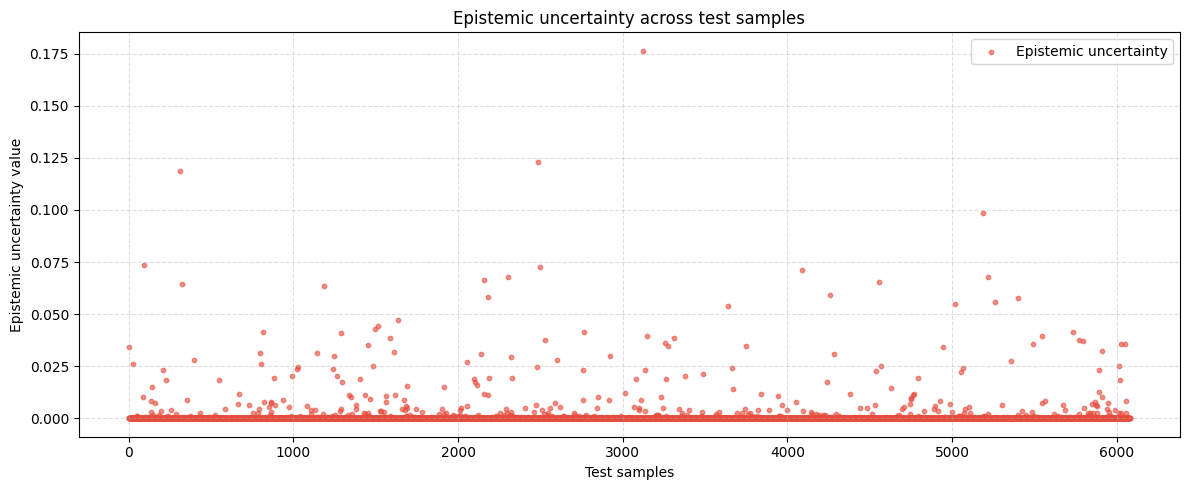

In [41]:
x = np.arange(1, 6081)

plt.figure(figsize=(12, 5))

# Scatter plot for uncertainty
plt.scatter(x, y_uncertainty, 
            s=10, 
            alpha=0.6, 
            color="#e74c3c",  # attractive red
            label="Epistemic uncertainty")

plt.xlabel("Test samples")
plt.ylabel("Epistemic uncertainty value")
plt.title("Epistemic uncertainty across test samples")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

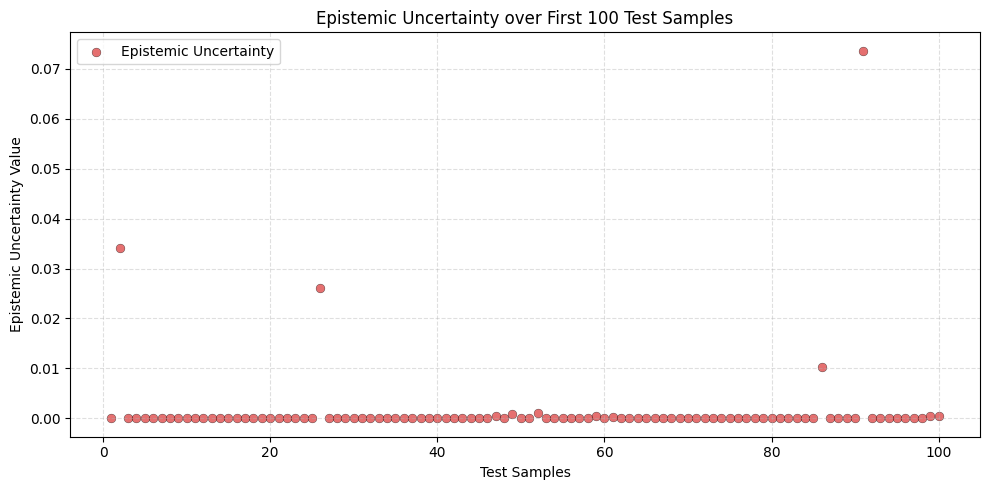

In [42]:
x = np.arange(1, 101)

plt.figure(figsize=(10, 5))

plt.scatter(x, y_uncertainty[:100],
            s=40,
            alpha=0.7,
            color="#db3434",  # nice blue
            edgecolor="black",
            linewidth=0.3,
            label="Epistemic Uncertainty")

plt.xlabel("Test Samples")
plt.ylabel("Epistemic Uncertainty Value")
plt.title("Epistemic Uncertainty over First 100 Test Samples")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()